In [1]:
# Now Decision Tree Classification model on ecomerce shopind data

import pandas as pd
import seaborn as sns
import numpy as np
import matplotlib.pyplot as plt

In [2]:
# Load the Daa 

data = pd.read_csv("shop_smart_ecommerce.csv")

In [3]:
data

,Administrative,Administrative_Duration,Informational,Informational_Duration,ProductRelated,ProductRelated_Duration,BounceRates,ExitRates,PageValues,SpecialDay,Month,OperatingSystems,Browser,Region,TrafficType,VisitorType,Weekend,Revenue
0,0,0.0,0,0.0,1,0.000000,0.200000,0.200000,0.000000,0.0,Feb,1,1,1,1,Returning_Visitor,False,False
1,0,0.0,0,0.0,2,64.000000,0.000000,0.100000,0.000000,0.0,Feb,2,2,1,2,Returning_Visitor,False,False
2,0,0.0,0,0.0,1,0.000000,0.200000,0.200000,0.000000,0.0,Feb,4,1,9,3,Returning_Visitor,False,False
3,0,0.0,0,0.0,2,2.666667,0.050000,0.140000,0.000000,0.0,Feb,3,2,2,4,Returning_Visitor,False,False
4,0,0.0,0,0.0,10,627.500000,0.020000,0.050000,0.000000,0.0,Feb,3,3,1,4,Returning_Visitor,True,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
12325,3,145.0,0,0.0,53,1783.791667,0.007143,0.029031,12.241717,0.0,Dec,4,6,1,1,Returning_Visitor,True,False
12326,0,0.0,0,0.0,5,465.750000,0.000000,0.021333,0.000000,0.0,Nov,3,2,1,8,Returning_Visitor,True,False
12327,0,0.0,0,0.0,6,184.250000,0.083333,0.086667,0.000000,0.0,Nov,3,2,1,13,Returning_Visitor,True,False
12328,4,75.0,0,0.0,15,346.000000,0.000000,0.021053,0.000000,0.0,Nov,2,2,3,11,Returning_Visitor,False,False


In [4]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 12330 entries, 0 to 12329
Data columns (total 18 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Administrative           12330 non-null  int64  
 1   Administrative_Duration  12330 non-null  float64
 2   Informational            12330 non-null  int64  
 3   Informational_Duration   12330 non-null  float64
 4   ProductRelated           12330 non-null  int64  
 5   ProductRelated_Duration  12330 non-null  float64
 6   BounceRates              12330 non-null  float64
 7   ExitRates                12330 non-null  float64
 8   PageValues               12330 non-null  float64
 9   SpecialDay               12330 non-null  float64
 10  Month                    12330 non-null  object 
 11  OperatingSystems         12330 non-null  int64  
 12  Browser                  12330 non-null  int64  
 13  Region                   12330 non-null  int64  
 14  TrafficType           

In [5]:
# Cheking Null values in data 

data.isnull().sum()

Administrative             0
Administrative_Duration    0
Informational              0
Informational_Duration     0
ProductRelated             0
ProductRelated_Duration    0
BounceRates                0
ExitRates                  0
PageValues                 0
SpecialDay                 0
Month                      0
OperatingSystems           0
Browser                    0
Region                     0
TrafficType                0
VisitorType                0
Weekend                    0
Revenue                    0
dtype: int64

In [6]:
data.sample(10)

,Administrative,Administrative_Duration,Informational,Informational_Duration,ProductRelated,ProductRelated_Duration,BounceRates,ExitRates,PageValues,SpecialDay,Month,OperatingSystems,Browser,Region,TrafficType,VisitorType,Weekend,Revenue
10323,5,218.833333,3,54.000000,28,1430.854167,0.018824,0.022958,9.509492,0.0,Dec,3,2,1,2,Returning_Visitor,True,False
7382,8,92.933333,0,0.000000,78,2063.642844,0.007407,0.011934,0.000000,0.0,Sep,3,2,6,13,Returning_Visitor,False,False
9643,1,0.000000,0,0.000000,77,4350.647321,0.012727,0.023843,14.385468,0.0,Nov,2,2,1,2,Returning_Visitor,False,False
901,0,0.000000,0,0.000000,9,465.500000,0.006667,0.056667,43.797174,0.0,Mar,2,2,1,1,Returning_Visitor,False,False
18,0,0.000000,0,0.000000,2,32.000000,0.000000,0.100000,0.000000,0.0,Feb,2,2,1,3,Returning_Visitor,False,False
3261,2,32.000000,0,0.000000,7,164.500000,0.000000,0.008333,0.000000,0.4,May,2,2,1,4,Returning_Visitor,False,False
9955,0,0.000000,0,0.000000,31,828.250000,0.012903,0.030108,0.000000,0.0,Nov,2,2,9,2,New_Visitor,True,False
6167,6,78.513333,1,63.400000,110,1691.236147,0.003448,0.019360,19.183108,0.0,Aug,2,2,7,4,Returning_Visitor,True,False
5013,0,0.000000,3,103.166667,21,1586.333333,0.016667,0.033333,0.000000,0.0,May,2,2,1,2,Returning_Visitor,False,False
9016,4,113.250000,0,0.000000,91,1746.108683,0.000000,0.004287,0.000000,0.0,Nov,2,2,8,8,New_Visitor,False,False


In [7]:
# Count the values in terget column 

data['Revenue'].value_counts()

Revenue
False    10422
True      1908
Name: count, dtype: int64

In [8]:
data.columns

Index(['Administrative', 'Administrative_Duration', 'Informational',
       'Informational_Duration', 'ProductRelated', 'ProductRelated_Duration',
       'BounceRates', 'ExitRates', 'PageValues', 'SpecialDay', 'Month',
       'OperatingSystems', 'Browser', 'Region', 'TrafficType', 'VisitorType',
       'Weekend', 'Revenue'],
      dtype='object')

In [9]:
# Label Encoding on Categorical columns 

from sklearn.preprocessing import LabelEncoder

enc = LabelEncoder()

cat_col = ["VisitorType", "Revenue"]

for col in cat_col:
    data[col] = enc.fit_transform(data[col])

In [10]:
# One Hot Encoding one Some Categorical colums

data = pd.get_dummies(data, columns = ["Month", "Weekend"], drop_first = True, dtype=int)

In [11]:
# Now Convert the values into X and y

X = data.drop(columns = "Revenue")
y = data["Revenue"]

In [12]:
# Split the data into Train and Test datasets 

from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size = 0.2, random_state = 42
)

In [13]:
X_train

,Administrative,Administrative_Duration,Informational,Informational_Duration,ProductRelated,ProductRelated_Duration,BounceRates,ExitRates,PageValues,SpecialDay,...,Month_Dec,Month_Feb,Month_Jul,Month_June,Month_Mar,Month_May,Month_Nov,Month_Oct,Month_Sep,Weekend_True
1785,0,0.000000,0,0.0,7,95.000000,0.014286,0.061905,0.000000,0.0,...,0,0,0,0,1,0,0,0,0,0
10407,2,14.000000,0,0.0,81,1441.910588,0.002469,0.013933,2.769599,0.0,...,0,0,0,0,0,0,1,0,0,0
286,0,0.000000,0,0.0,1,0.000000,0.200000,0.200000,0.000000,0.0,...,0,0,0,0,1,0,0,0,0,0
6520,5,49.200000,4,379.0,5,74.600000,0.000000,0.018182,8.326728,0.0,...,0,0,0,0,0,0,0,0,1,0
12251,0,0.000000,1,5.0,9,279.000000,0.040000,0.041667,0.000000,0.0,...,0,0,0,0,0,0,1,0,0,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
11964,14,1005.608333,0,0.0,25,732.344872,0.000000,0.015676,0.000000,0.0,...,0,0,0,0,0,0,1,0,0,0
5191,0,0.000000,0,0.0,14,340.000000,0.000000,0.015385,23.388000,0.0,...,0,0,0,0,0,1,0,0,0,1
5390,0,0.000000,0,0.0,3,189.000000,0.000000,0.066667,0.000000,0.0,...,0,0,0,0,0,1,0,0,0,0
860,0,0.000000,0,0.0,13,305.000000,0.000000,0.016667,0.000000,0.0,...,0,0,0,0,1,0,0,0,0,0


In [14]:
# Import the model to train 

from sklearn.tree import DecisionTreeClassifier

tree_model = DecisionTreeClassifier()

tree_model.fit(X_train, y_train)

DecisionTreeClassifier()

In [15]:
# Predict the Output from the model \

y_pred = tree_model.predict(X_test)

In [42]:
# Check the acccuracy score and F1 score of the model 
from sklearn.metrics import f1_score, accuracy_score

print("f1 score", f1_score(y_test, y_pred))

f1 score 0.5256609642301711


In [17]:
# See the F1 Score of the model is 0.558

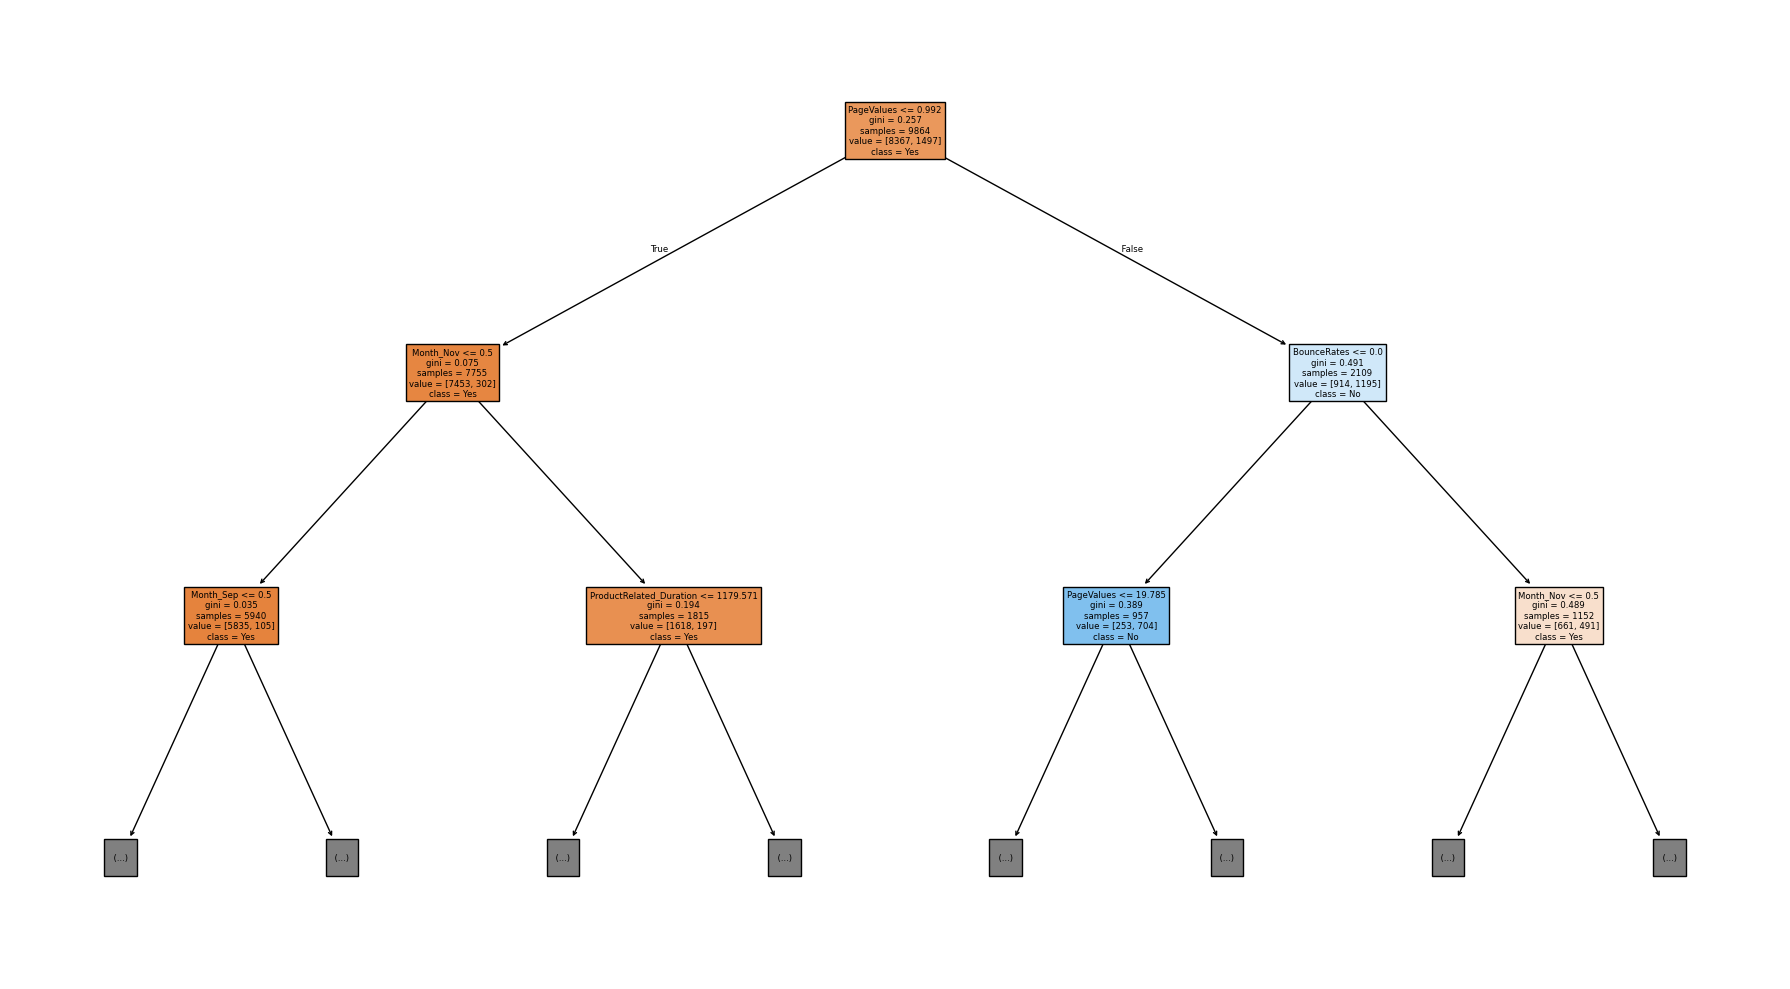

In [38]:
from sklearn.tree import plot_tree

plt.figure(figsize=(18, 10))
plot_tree(
    tree_model,
    feature_names=X.columns,
    class_names = ['Yes', 'No'],
    filled = True,
    max_depth = 2
)

plt.tight_layout()
plt.show()

depth :  2 accuracy :  0.8763179237631792
depth :  3 accuracy :  0.8884833738848338
depth :  4 accuracy :  0.8929440389294404
depth :  5 accuracy :  0.8884833738848338
depth :  6 accuracy :  0.8933495539334956


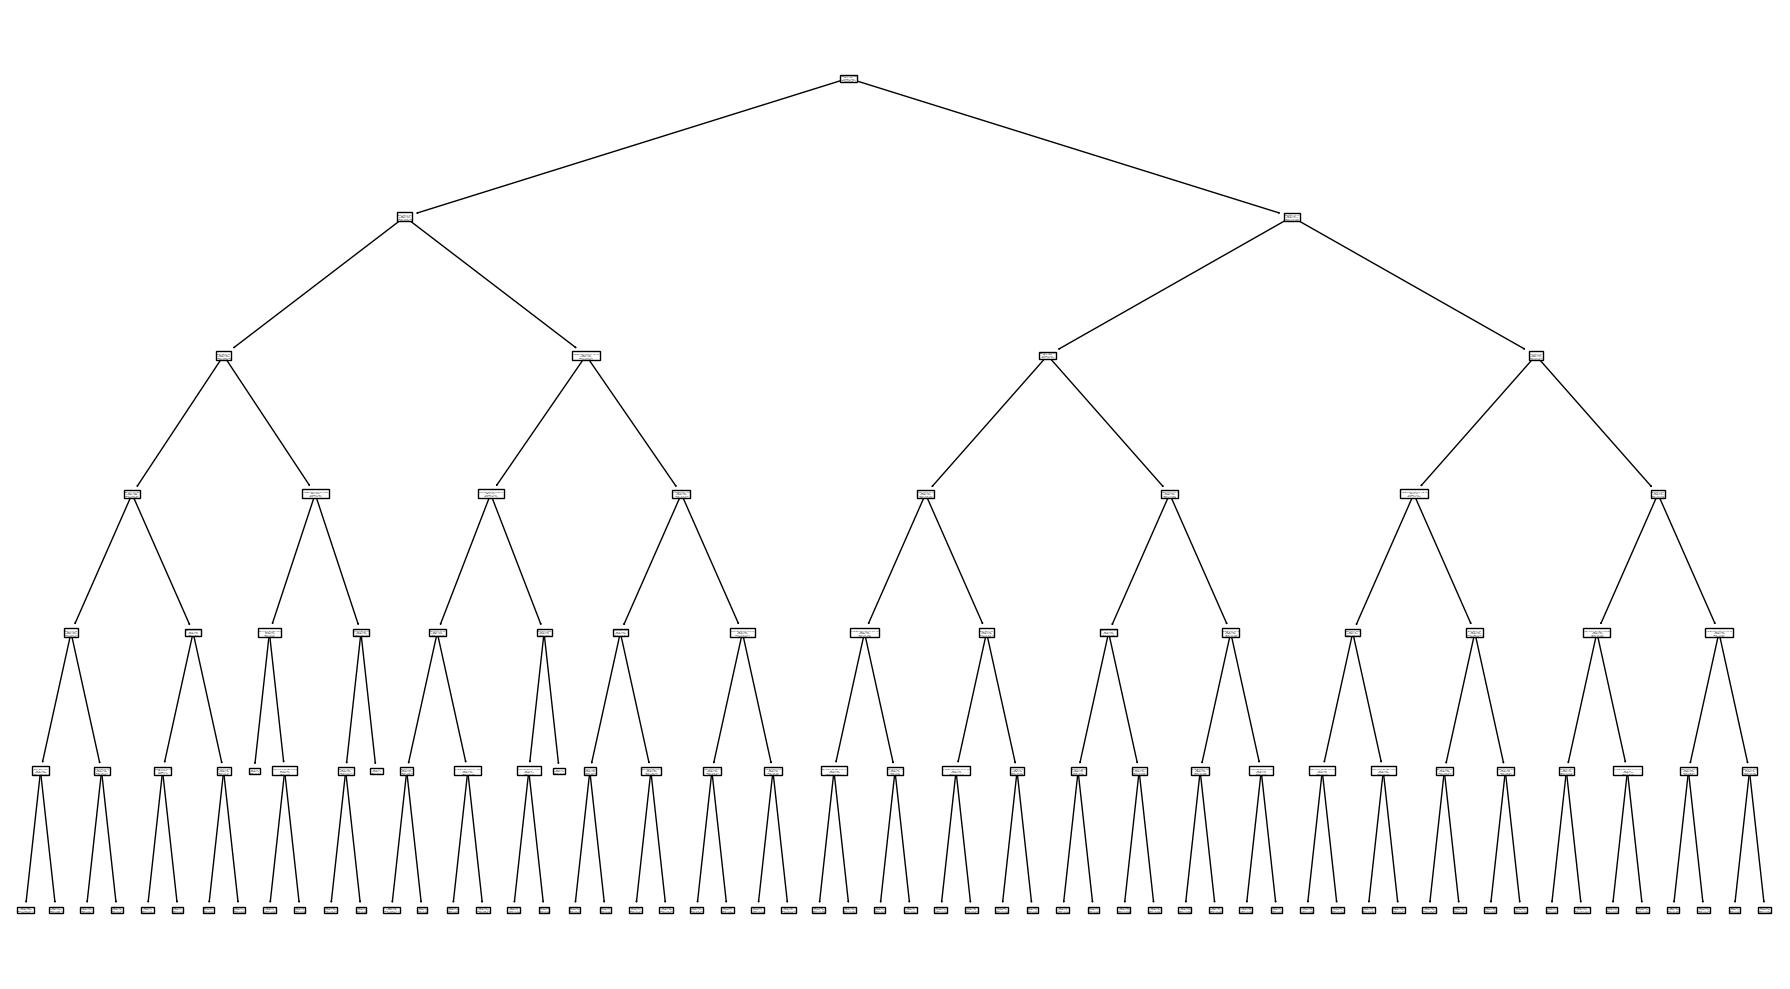

depth :  7 accuracy :  0.8901054339010543
depth :  8 accuracy :  0.8880778588807786
depth :  9 accuracy :  0.878345498783455
depth :  10 accuracy :  0.8803730738037308


In [44]:
# Decision tree with pre pruning 

max_depths = [2, 3, 4, 5, 6, 7, 8, 9, 10]

for depth in max_depths:

    model = DecisionTreeClassifier(max_depth=depth)
    model.fit(X_train, y_train)

    y_pred = model.predict(X_test)
    print(f'depth : ', depth, 'accuracy : ', accuracy_score(y_test, y_pred))
    
    # acc = model.score(X_test, y_test)
    # print(f"for depth={depth}, accuracy={acc}")
    
    if depth == 6:
        plt.figure(figsize=(18, 10))
        plot_tree(
            model,
            feature_names = X.columns,
            class_names = ['Died', 'Survived']
        )
        plt.tight_layout()
        plt.show()